# Store Sales Forecasting - 01 Data Understanding and Preparation

This notebook prepares the store sales dataset for a later supervised learning / PyTorch forecasting model.

The goal of this first part is to:

1. Load `train.csv`, `test.csv`, and `store.csv`.
2. Understand the available columns, dates, missing values, and target variable.
3. Merge store metadata into the daily sales data.
4. Clean missing values in a reproducible way.
5. Create useful time-series and store-related features.
6. Create a chronological train/validation split.
7. Save prepared files for the modeling step.

Important: `Customers` is removed from the model features because it is available in `train.csv` but not in `test.csv`, so using it would create a mismatch and possible data leakage.

## 1. Imports and Settings

For a limited computer, keep `USE_SAMPLE = True`. For the final experiment, set it to `False` and rerun the notebook.

In [57]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

DATA_DIR = Path("Data")
OUTPUT_DIR = Path("outputs/prepared_notebook")

# Lightweight mode for school laptops / quick experiments.
USE_SAMPLE = True
SAMPLE_STORES = 100
MIN_DATE = "2014-01-01"

# Final validation period: the last 6 weeks of training data.
VALIDATION_DAYS = 42
RANDOM_STATE = 42

## 2. Load the Raw Data

In [58]:
train = pd.read_csv(
    DATA_DIR / "train.csv",
    parse_dates=["Date"],
    dtype={"StateHoliday": "string"},
    low_memory=False,
)

test = pd.read_csv(
    DATA_DIR / "test.csv",
    parse_dates=["Date"],
    dtype={"StateHoliday": "string"},
    low_memory=False,
)

store = pd.read_csv(DATA_DIR / "store.csv", low_memory=False)

RAW_TRAIN_SHAPE = train.shape
RAW_TEST_SHAPE = test.shape
RAW_STORE_SHAPE = store.shape

print("train shape:", train.shape)
print("test shape:", test.shape)
print("store shape:", store.shape)

train shape: (1017209, 9)
test shape: (41088, 8)
store shape: (1115, 10)


## 3. Data Understanding

We inspect the columns, date ranges, missing values, and basic target distribution.

In [59]:
def summarize_dataframe(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    
    if "Date" in df.columns:
        print("date range:", df["Date"].min().date(), "to", df["Date"].max().date())
    
    if "Store" in df.columns:
        print("number of stores:", df["Store"].nunique())
    
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print("missing values:")
    display(missing.to_frame("missing_rows"))
    
    display(df.head())


summarize_dataframe(train, "train.csv")
summarize_dataframe(test, "test.csv")
summarize_dataframe(store, "store.csv")


train.csv
---------
shape: (1017209, 9)
columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
date range: 2013-01-01 to 2015-07-31
number of stores: 1115
missing values:


,missing_rows


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



test.csv
--------
shape: (41088, 8)
columns: ['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
date range: 2015-08-01 to 2015-09-17
number of stores: 856
missing values:


,missing_rows
Open,11


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0



store.csv
---------
shape: (1115, 10)
columns: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
number of stores: 1115
missing values:


,missing_rows
Promo2SinceYear,544
Promo2SinceWeek,544
PromoInterval,544
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
CompetitionDistance,3


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [60]:
print("Sales summary:")
display(train["Sales"].describe().to_frame())

print("Rows with zero sales:", int((train["Sales"] == 0).sum()))
print("Rows where store is closed:", int((train["Open"] == 0).sum()))

print("Average sales by Open flag:")
display(train.groupby("Open")["Sales"].agg(["count", "mean", "median", "min", "max"]))

print("Average sales by promotion flag:")
display(train.groupby("Promo")["Sales"].agg(["count", "mean", "median"]))

Sales summary:


,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


Rows with zero sales: 172871
Rows where store is closed: 172817
Average sales by Open flag:


,count,mean,median,min,max
Open,,,,,
0,172817,0.000000,0.0,0,0
1,844392,6955.514291,6369.0,0,41551


Average sales by promotion flag:


,count,mean,median
Promo,,,
0,629129,4406.050805,4622.0
1,388080,7991.152046,7553.0


## 4. Optional Down-Sampling

The full dataset has more than one million training rows. For fast experimentation, we can keep only a subset of stores and/or recent dates. This is useful while developing the project. Later, we can disable sampling and rerun everything.

In [61]:
if USE_SAMPLE:
    rng = np.random.default_rng(RANDOM_STATE)
    selected_stores = sorted(
        rng.choice(sorted(train["Store"].unique()), size=SAMPLE_STORES, replace=False)
    )
    
    train = train[train["Store"].isin(selected_stores)].copy()
    test = test[test["Store"].isin(selected_stores)].copy()
    train = train[train["Date"] >= pd.Timestamp(MIN_DATE)].copy()
    
    print(f"Using a sample of {len(selected_stores)} stores from {MIN_DATE} onward.")
else:
    selected_stores = None
    print("Using the full dataset.")

print("train shape after sampling:", train.shape)
print("test shape after sampling:", test.shape)

Using a sample of 100 stores from 2014-01-01 onward.
train shape after sampling: (55308, 9)
test shape after sampling: (3456, 8)


## 5. Merge Store Metadata

`store.csv` contains information such as store type, assortment, competition distance, and long-running promotions. We merge this information into every train and test row.

In [62]:
train = train.merge(store, on="Store", how="left", validate="many_to_one")
test = test.merge(store, on="Store", how="left", validate="many_to_one")

print("train shape after merge:", train.shape)
print("test shape after merge:", test.shape)

if train["StoreType"].isna().any() or test["StoreType"].isna().any():
    raise ValueError("Some stores do not have metadata in store.csv")

train shape after merge: (55308, 18)
test shape after merge: (3456, 17)


## 6. Clean Missing Values

Cleaning rules used here:

- Missing `Open` in the test set is filled with `1`, because most stores are open unless explicitly marked closed.
- Missing `CompetitionDistance` is filled with the median distance.
- Missing competition and Promo2 date parts are filled with `0`, meaning "not known / not active".
- Missing `PromoInterval` is filled with an empty string.
- `StateHoliday` is normalized because the raw files can mix string and numeric-looking values.

In [63]:
def clean_dataframe(df, competition_distance_fill):
    df = df.copy()
    
    df["StateHoliday"] = (
        df["StateHoliday"]
        .astype("string")
        .fillna("0")
        .str.strip()
        .str.lower()
        .replace({"0.0": "0", "nan": "0", "none": "0"})
    )
    
    df["Open"] = df["Open"].fillna(1).astype(int)
    df["Promo"] = df["Promo"].fillna(0).astype(int)
    df["SchoolHoliday"] = df["SchoolHoliday"].fillna(0).astype(int)
    df["Promo2"] = df["Promo2"].fillna(0).astype(int)
    
    df["StoreType"] = df["StoreType"].fillna("missing").astype(str)
    df["Assortment"] = df["Assortment"].fillna("missing").astype(str)
    df["PromoInterval"] = df["PromoInterval"].fillna("").astype(str)
    
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(competition_distance_fill)
    
    date_part_columns = [
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear",
    ]
    for column in date_part_columns:
        df[column] = df[column].fillna(0).astype(int)
    
    return df


competition_distance_fill = float(store["CompetitionDistance"].median())
train = clean_dataframe(train, competition_distance_fill)
test = clean_dataframe(test, competition_distance_fill)

print("Remaining missing values in train:")
display(train.isna().sum()[lambda s: s > 0].to_frame("missing_rows"))

print("Remaining missing values in test:")
display(test.isna().sum()[lambda s: s > 0].to_frame("missing_rows"))

Remaining missing values in train:


,missing_rows


Remaining missing values in test:


,missing_rows


## 7. Feature Engineering

We create features that are available both in historical data and in the future test data. At this stage we avoid lag features, because those require extra care and will be more appropriate in the modeling notebook.

In [64]:
global_start_date = min(train["Date"].min(), test["Date"].min())


def add_features(df):
    df = df.copy()
    date = pd.to_datetime(df["Date"])
    iso_calendar = date.dt.isocalendar()
    
    # Calendar features.
    df["year"] = date.dt.year.astype(int)
    df["month"] = date.dt.month.astype(int)
    df["day"] = date.dt.day.astype(int)
    df["weekofyear"] = iso_calendar.week.astype(int)
    df["quarter"] = date.dt.quarter.astype(int)
    df["dayofyear"] = date.dt.dayofyear.astype(int)
    df["is_weekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)
    df["is_month_start"] = date.dt.is_month_start.astype(int)
    df["is_month_end"] = date.dt.is_month_end.astype(int)
    df["days_since_start"] = (date - global_start_date).dt.days.astype(int)
    
    # Cyclical encodings help neural networks understand repeating calendar patterns.
    df["dow_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    # Months since competition opened. Unknown or future competition dates become 0.
    valid_competition_date = (
        (df["CompetitionOpenSinceYear"] > 0)
        & (df["CompetitionOpenSinceMonth"] >= 1)
        & (df["CompetitionOpenSinceMonth"] <= 12)
    )
    competition_months = (
        (df["year"] - df["CompetitionOpenSinceYear"]) * 12
        + (df["month"] - df["CompetitionOpenSinceMonth"])
    )
    df["competition_open_months"] = np.where(valid_competition_date, competition_months, 0)
    df["competition_open_months"] = np.clip(df["competition_open_months"], 0, None).astype(int)
    
    # Whether Promo2 is active in the current month.
    month_abbr = date.dt.strftime("%b")
    month_is_in_interval = np.array([
        month in interval.split(",")
        for month, interval in zip(month_abbr, df["PromoInterval"].fillna(""))
    ])
    valid_promo2_start = (df["Promo2SinceYear"] > 0) & (df["Promo2SinceWeek"] > 0)
    promo2_start = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
    year_text = df.loc[valid_promo2_start, "Promo2SinceYear"].astype(str)
    week_text = df.loc[valid_promo2_start, "Promo2SinceWeek"].astype(str).str.zfill(2)
    promo2_start.loc[valid_promo2_start] = pd.to_datetime(
        year_text + "-W" + week_text + "-1",
        format="%G-W%V-%u",
        errors="coerce",
    )
    df["promo2_active"] = (
        (df["Promo2"] == 1)
        & month_is_in_interval
        & promo2_start.notna()
        & (date >= promo2_start)
    ).astype(int)
    
    return df


train = add_features(train)
test = add_features(test)

display(train.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,quarter,dayofyear,is_weekend,is_month_start,is_month_end,days_since_start,dow_sin,dow_cos,month_sin,month_cos,competition_open_months,promo2_active
0,47,5,2015-07-31,9379,1021,1,1,0,1,a,c,270.0,4,2013,1,14,2013,"Jan,Apr,Jul,Oct",2015,7,31,31,3,212,0,0,1,576,-0.974928,-0.222521,-0.5,-0.866025,27,0
1,68,5,2015-07-31,11187,1341,1,1,0,1,a,c,250.0,0,0,1,35,2012,"Mar,Jun,Sept,Dec",2015,7,31,31,3,212,0,0,1,576,-0.974928,-0.222521,-0.5,-0.866025,0,0
2,72,5,2015-07-31,5251,520,1,1,0,0,a,a,2200.0,12,2009,1,13,2010,"Jan,Apr,Jul,Oct",2015,7,31,31,3,212,0,0,1,576,-0.974928,-0.222521,-0.5,-0.866025,67,0
3,83,5,2015-07-31,3866,327,1,1,0,1,a,a,2710.0,0,0,0,0,0,,2015,7,31,31,3,212,0,0,1,576,-0.974928,-0.222521,-0.5,-0.866025,0,0
4,88,5,2015-07-31,7863,776,1,1,0,1,a,a,10690.0,10,2005,0,0,0,,2015,7,31,31,3,212,0,0,1,576,-0.974928,-0.222521,-0.5,-0.866025,117,0


## 7.1 Continuous Variables Over Time

The dataset has one row per store per day, so plotting every raw point would be very crowded. We also avoid plotting variables that are not useful as continuous time-series charts:

- binary variables with only `0` and `1` values, such as `Open`, `Promo`, and holiday flags;
- calendar sequence variables such as `month`, `weekofyear`, and `days_since_start`, because they only describe the passage of time;
- categorical identifiers stored as numbers, such as `Store` and `DayOfWeek`.

For the remaining continuous variables, we plot grouped time trends using weekly and monthly averages.

Continuous variables plotted: 3
['Sales', 'Customers', 'CompetitionDistance']

Binary variables excluded:
['Open', 'Promo', 'SchoolHoliday', 'Promo2', 'is_weekend', 'is_month_start', 'is_month_end']

Temporal/categorical variables excluded:
['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'DayOfWeek', 'Promo2SinceWeek', 'Promo2SinceYear', 'Store', 'competition_open_months', 'day', 'dayofyear', 'days_since_start', 'dow_cos', 'dow_sin', 'month', 'month_cos', 'month_sin', 'quarter', 'weekofyear', 'year']


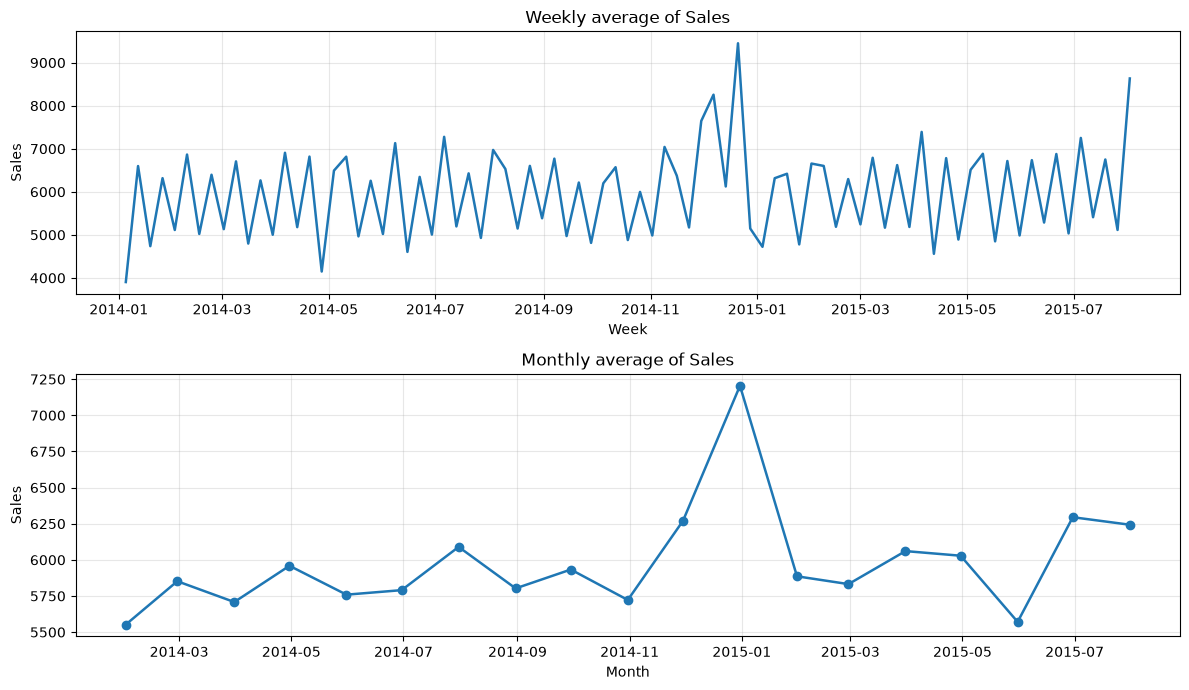

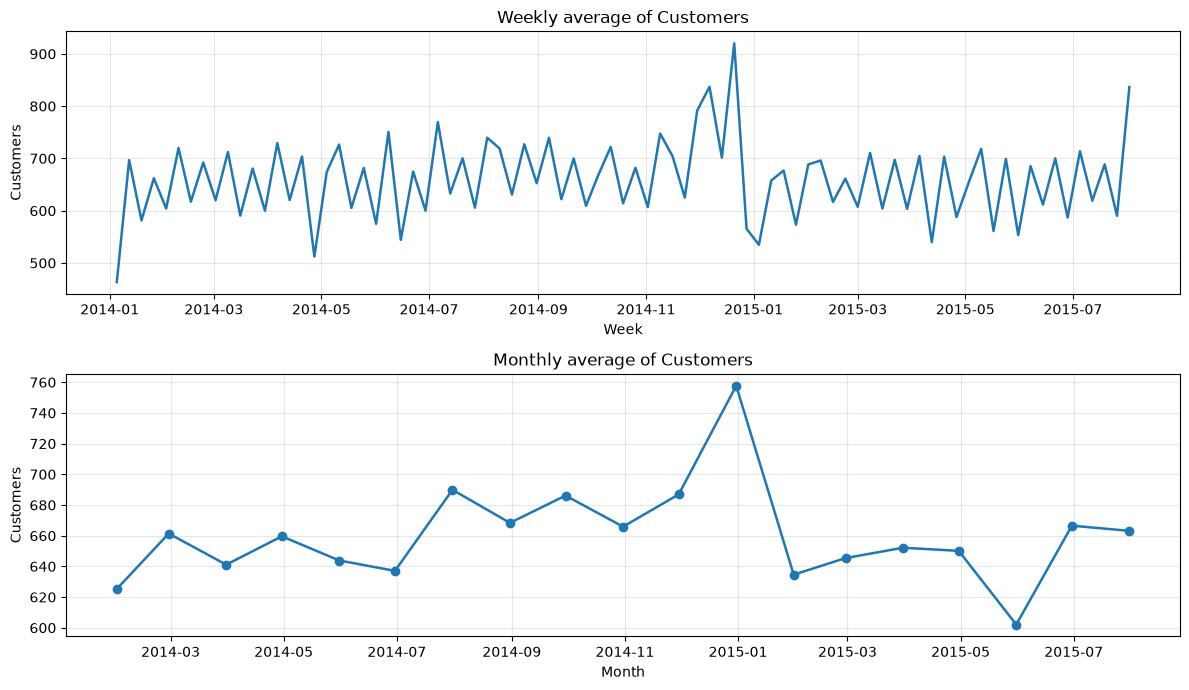

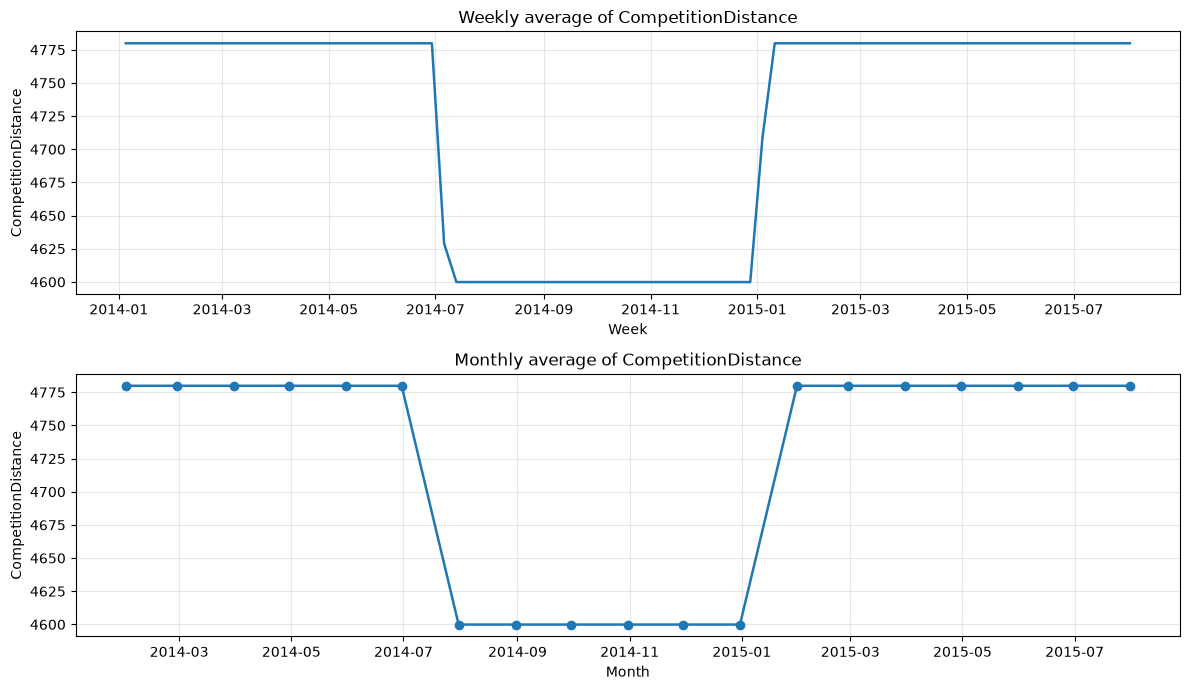

In [65]:
numeric_columns = list(train.select_dtypes(include=[np.number]).columns)

identifier_or_categorical_columns = [
    "Store",
    "DayOfWeek",
]

temporal_sequence_columns = [
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "year",
    "month",
    "day",
    "weekofyear",
    "quarter",
    "dayofyear",
    "days_since_start",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "competition_open_months",
]

def is_binary_column(series):
    values = set(series.dropna().unique())
    return len(values) > 0 and values.issubset({0, 1})


excluded_columns = set(identifier_or_categorical_columns + temporal_sequence_columns)

continuous_columns_to_plot = []
excluded_binary_columns = []

for column in numeric_columns:
    if column in excluded_columns:
        continue
    if train[column].nunique(dropna=True) <= 1:
        continue
    if is_binary_column(train[column]):
        excluded_binary_columns.append(column)
        continue
    continuous_columns_to_plot.append(column)

weekly_means = (
    train.set_index("Date")[continuous_columns_to_plot]
    .resample("W")
    .mean()
)

monthly_means = train.set_index("Date")[continuous_columns_to_plot].resample("ME").mean()

print(f"Continuous variables plotted: {len(continuous_columns_to_plot)}")
print(continuous_columns_to_plot)
print("\nBinary variables excluded:")
print(excluded_binary_columns)
print("\nTemporal/categorical variables excluded:")
print(sorted(excluded_columns.intersection(numeric_columns)))

for column in continuous_columns_to_plot:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
    
    axes[0].plot(weekly_means.index, weekly_means[column], linewidth=1.8)
    axes[0].set_title(f"Weekly average of {column}")
    axes[0].set_xlabel("Week")
    axes[0].set_ylabel(column)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(monthly_means.index, monthly_means[column], marker="o", linewidth=1.8)
    axes[1].set_title(f"Monthly average of {column}")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel(column)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Chronological Train / Validation Split

For time-series forecasting, validation must come after training in time. Here we use the most recent 42 days of `train.csv` as validation.

In [66]:
train = train.sort_values(["Store", "Date"]).reset_index(drop=True)
test = test.sort_values(["Date", "Store"]).reset_index(drop=True)

max_train_date = train["Date"].max()
validation_start = max_train_date - pd.Timedelta(days=VALIDATION_DAYS - 1)

train_prepared = train[train["Date"] < validation_start].copy()
validation_prepared = train[train["Date"] >= validation_start].copy()
test_prepared = test.copy()

print("train period:", train_prepared["Date"].min().date(), "to", train_prepared["Date"].max().date())
print("validation period:", validation_prepared["Date"].min().date(), "to", validation_prepared["Date"].max().date())
print("test period:", test_prepared["Date"].min().date(), "to", test_prepared["Date"].max().date())

print("train rows:", len(train_prepared))
print("validation rows:", len(validation_prepared))
print("test rows:", len(test_prepared))

train period: 2014-01-01 to 2015-06-19
validation period: 2015-06-20 to 2015-07-31
test period: 2015-08-01 to 2015-09-17
train rows: 51108
validation rows: 4200
test rows: 3456


## 9. Define Features for Later Modeling

These feature lists will be useful in the PyTorch notebook. We keep categorical and numeric columns separated because categorical variables can later be represented with embeddings.

In [67]:
target_column = "Sales"

leakage_columns_not_used = ["Customers"]

categorical_features = [
    "Store",
    "DayOfWeek",
    "StateHoliday",
    "StoreType",
    "Assortment",
]

numeric_features = [
    "Open",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "year",
    "month",
    "day",
    "weekofyear",
    "quarter",
    "dayofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "days_since_start",
    "competition_open_months",
    "promo2_active",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

model_features = categorical_features + numeric_features

print("target:", target_column)
print("categorical features:", len(categorical_features))
print("numeric features:", len(numeric_features))
print("total model features:", len(model_features))
print("excluded leakage columns:", leakage_columns_not_used)

target: Sales
categorical features: 5
numeric features: 25
total model features: 30
excluded leakage columns: ['Customers']


## 9.1 Selected features

In [68]:
relevant_features = [
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Open",
    "DayOfWeek",
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "dow_sin", #dow and month are turned to sin and cos to makes them numerical while maintaining the circularity of the data.
    "dow_cos",
    "month_sin",
    "month_cos",
    "competition_open_months", #the duration in time of how much a competitor is open
    "promo2_active" #the relevant infos of all the promo2 stuff
]

print("Relevant features:")
print(relevant_features)

Relevant features:
['Promo', 'StateHoliday', 'SchoolHoliday', 'Open', 'DayOfWeek', 'StoreType', 'Assortment', 'CompetitionDistance', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'competition_open_months', 'promo2_active']


## 9.2 Diffusion Matrix

Here we calculate the correlation between the selected `relevant_features` and the target variable `Sales`. Since some relevant features are categorical, such as `StateHoliday`, `StoreType`, and `Assortment`, we first transform them with one-hot encoding. The result is a correlation matrix that helps us understand which variables are more strongly related to sales.

For a regression problem this is usually called a **correlation matrix**. We keep the title "Diffusion Matrix" because it is the name chosen for this project section.

Correlation with Sales, sorted by absolute value:


,correlation_with_sales
Open,0.684556
DayOfWeek,-0.469668
Promo,0.448214
dow_cos,-0.312629
StateHoliday_0,0.259206
StateHoliday_a,-0.208180
Assortment_a,-0.143221
Assortment_c,0.142114
StateHoliday_b,-0.126156
dow_sin,0.110020


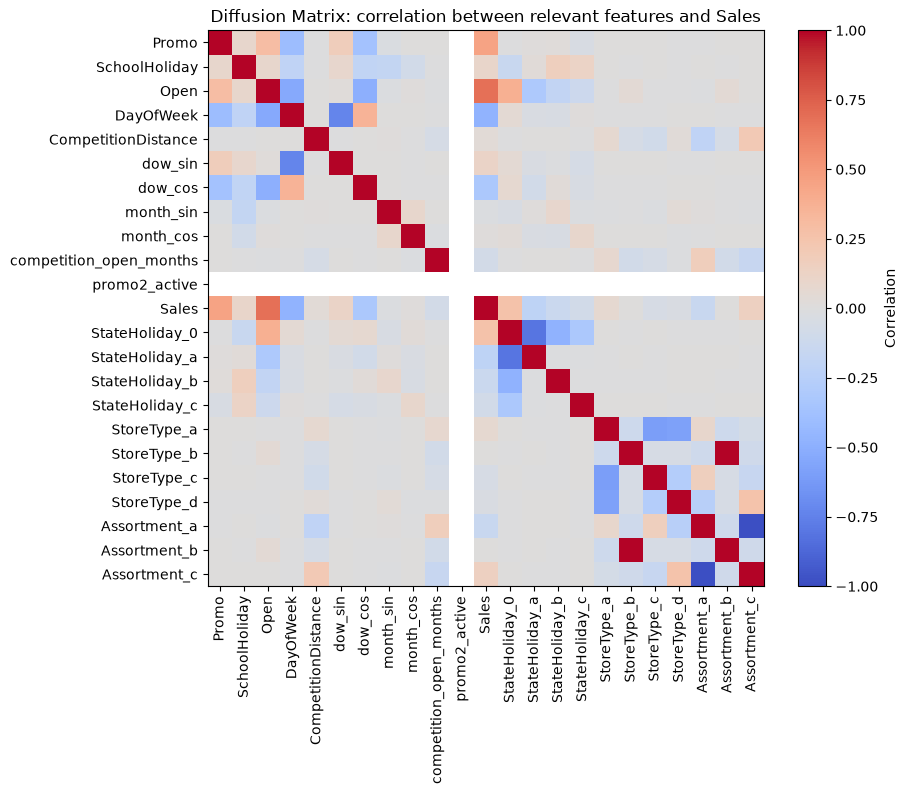

In [69]:
# Use all historical rows with known Sales for this exploratory analysis.
historical_prepared = pd.concat([train_prepared, validation_prepared], axis=0).copy()

# Keep only selected features that are actually present in the prepared dataset.
available_relevant_features = [
    column for column in relevant_features
    if column in historical_prepared.columns
]

missing_relevant_features = [
    column for column in relevant_features
    if column not in historical_prepared.columns
]

if missing_relevant_features:
    print("Relevant features not found and therefore excluded:")
    print(missing_relevant_features)

correlation_input = historical_prepared[available_relevant_features + [target_column]].copy()

# One-hot encode categorical features so they can be included in correlation analysis.
correlation_encoded = pd.get_dummies(correlation_input, drop_first=False)
correlation_matrix = correlation_encoded.corr(numeric_only=True)

sales_correlations = (
    correlation_matrix[target_column]
    .drop(target_column)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

print("Correlation with Sales, sorted by absolute value:")
display(sales_correlations.to_frame("correlation_with_sales"))

plt.figure(figsize=(max(10, 0.45 * len(correlation_matrix.columns)), max(8, 0.35 * len(correlation_matrix.columns))))
im = plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Diffusion Matrix: correlation between relevant features and Sales")
plt.tight_layout()
plt.show()

## 10. Save Prepared Files

The next notebook/script can load these files directly instead of repeating all preparation steps.

In [70]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_prepared.to_csv(OUTPUT_DIR / "train_prepared.csv", index=False)
validation_prepared.to_csv(OUTPUT_DIR / "validation_prepared.csv", index=False)
test_prepared.to_csv(OUTPUT_DIR / "test_prepared.csv", index=False)

data_summary = {
    "settings": {
        "use_sample": USE_SAMPLE,
        "sample_stores": SAMPLE_STORES if USE_SAMPLE else None,
        "min_date": MIN_DATE if USE_SAMPLE else None,
        "validation_days": VALIDATION_DAYS,
        "random_state": RANDOM_STATE,
    },
    "raw_shapes": {
        "train": list(RAW_TRAIN_SHAPE),
        "test": list(RAW_TEST_SHAPE),
        "store": list(RAW_STORE_SHAPE),
    },
    "prepared_shapes": {
        "train": list(train_prepared.shape),
        "validation": list(validation_prepared.shape),
        "test": list(test_prepared.shape),
    },
    "date_ranges": {
        "train": [str(train_prepared["Date"].min().date()), str(train_prepared["Date"].max().date())],
        "validation": [str(validation_prepared["Date"].min().date()), str(validation_prepared["Date"].max().date())],
        "test": [str(test_prepared["Date"].min().date()), str(test_prepared["Date"].max().date())],
    },
    "feature_lists": {
        "target": target_column,
        "categorical_features": categorical_features,
        "numeric_features": numeric_features,
        "model_features": model_features,
        "relevant_features": relevant_features,
        "leakage_columns_not_used": leakage_columns_not_used,
    },
}

with open(OUTPUT_DIR / "data_summary.json", "w", encoding="utf-8") as f:
    json.dump(data_summary, f, indent=2)

print("Saved prepared files in:", OUTPUT_DIR.resolve())
print("Files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Saved prepared files in: C:\Users\Palum\OneDrive\Desktop\Dottorato IA\(IML) Introduction to Machine Learning\Project2\THEBESTONETHEREIS\outputs\prepared_notebook
Files:
- data_summary.json
- test_prepared.csv
- train_prepared.csv
- validation_prepared.csv


## 11. What We Have Prepared

At the end of this notebook we have:

- `train_prepared.csv`: historical rows before the validation window.
- `validation_prepared.csv`: the most recent historical rows, used to evaluate forecasting performance.
- `test_prepared.csv`: future rows where the final model will predict `Sales`.
- `data_summary.json`: useful metadata about the split and feature lists.

Next step: formulate the supervised learning task and build a PyTorch regression model that predicts `log1p(Sales)` from these prepared features.